In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

In [3]:
pip install matplotlib

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLEOFError(8, 'EOF occurred in violation of protocol (_ssl.c:1129)'))) - skipping



In [4]:
df = pd.read_csv("student_data_cleaned.csv")

In [4]:
len(df)
4/6377

0.0006272541947624275

In [5]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [88]:
len(df)

6377

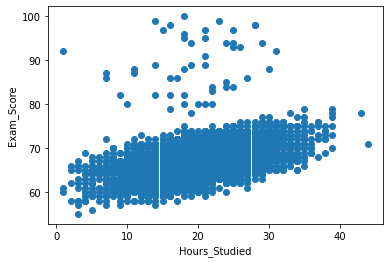

In [5]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.show()

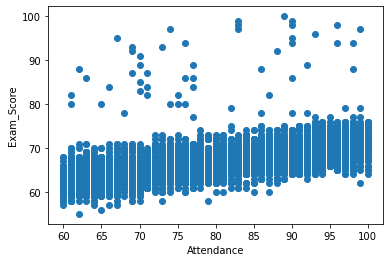

In [6]:
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam_Score")
plt.show()

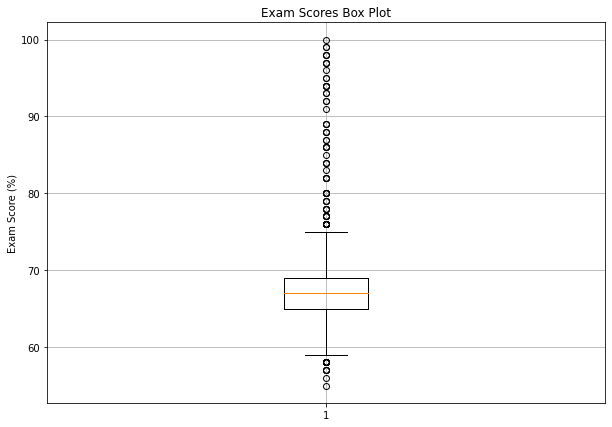

In [7]:
#boxplot for exam scores
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df["Exam_Score"]) # The function takes one or more datasets as input

# Add titles and labels
plt.title("Exam Scores Box Plot")
plt.ylabel("Exam Score (%)")
plt.grid(True)

# Display the plot
plt.show()
#box plot shows no clumping at ceiling (100%) or floor (0%)

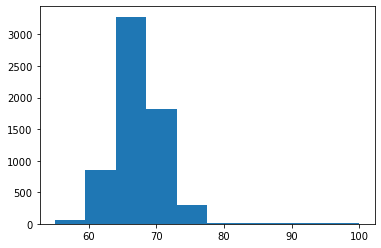

In [20]:
#histogram for exam scores
plt.hist(df["Exam_Score"])
plt.show()

Start by fitting a linear regression as follows: Exam_Score ~ Attendance
            + Previous_Scores
            + Hours_Studied
            + Motivation_Level
            + Sleep_Hours
            + Tutoring_Sessions
            + Family_Income
            + Parental_Education_Level
            + Parental_Involvement
            + Teacher_Quality
            + School_Type
            + Learning_Disabilities
            + Gender
            
Not included:
Access_to_Resources,
Extracurricular_Activities,
Internet_Access,
Peer_Influence,
Physical_Activity,
Distance_from_Home

In [9]:
lm = smf.ols("""
Exam_Score ~ Attendance
+ Previous_Scores
+ Hours_Studied
+ C(Motivation_Level)
+ Sleep_Hours
+ Tutoring_Sessions
+ C(Family_Income)
+ C(Parental_Education_Level)
+ C(Parental_Involvement)
+ C(Teacher_Quality)
+ C(School_Type)
+ C(Learning_Disabilities)
+ C(Gender)
""", data=df).fit()

lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Exam_Score   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     701.2
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        14:00:58   Log-Likelihood:                -14226.
No. Observations:                6377   AIC:                         2.849e+04
Df Residuals:                    6358   BIC:                         2.862e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                      44.0794      0.326    135.118      0.000      43.440      44.719
C(Motivation_Level)[T.Low]                     -1.1056      0.082    -13.474      0.000      -1.266      -0.945
C(Motivation_Level)[T.Medium]                  -0.5212      0.075     -6.983      0.000      -0.668      -0.375
C(Family_Income)[T.Low]                        -1.0638      0.078    -13.598      0.000      -1.217      -0.910
C(Family_Income)[T.Medium]                     -0.5622      0.078     -7.180      0.000      -0.716      -0.409
C(Parental_Education_Level)[T.High School]     -0.4668      0.065     -7.166      0.000      -0.595      -0.339
C(Parental_Education_Level)[T.Postgraduate]     0.5096      0.081      6.268      0.000       0.350       0.669
C(Parental_Involvement)[T.Low]                 -1.9596      0.082    -23.883      0.000      -2.120      -1.799
C(Parental_Involvement)[T.Medium]              -1.0353      0.066    -15.708      0.000      -1.164      -0.906
C(Teacher_Quality)[T.Low]                      -1.0051      0.103     -9.778      0.000      -1.207      -0.804
C(Teacher_Quality)[T.Medium]                   -0.5144      0.063     -8.127      0.000      -0.639      -0.390
C(School_Type)[T.Public]                       -0.0068      0.061     -0.111      0.912      -0.127       0.114
C(Learning_Disabilities)[T.Yes]                -0.8742      0.092     -9.466      0.000      -1.055      -0.693
C(Gender)[T.Male]                              -0.0116      0.057     -0.203      0.839      -0.124       0.101
Attendance                                      0.1969      0.002     80.390      0.000       0.192       0.202
Previous_Scores                                 0.0494      0.002     25.125      0.000       0.046       0.053
Hours_Studied                                   0.2930      0.005     62.029      0.000       0.284       0.302
Sleep_Hours                                    -0.0094      0.019     -0.487      0.626      -0.047       0.028
Tutoring_Sessions                               0.4854      0.023     21.183      0.000       0.440       0.530
==============================================================================
Omnibus:                     9106.164   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2457084.275
Skew:                           8.603   Prob(JB):                         0.00
Kurtosis:                      97.611   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. 

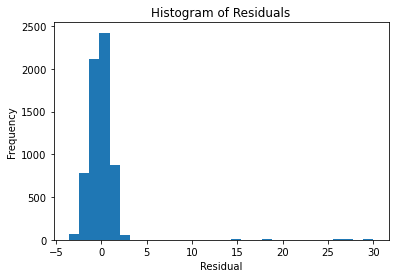

In [10]:
#plot of residuals
res = lm.resid

plt.hist(res, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

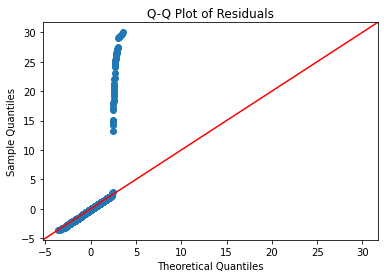

In [11]:
#QQ plot to assess normality of residuals
sm.qqplot(res, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

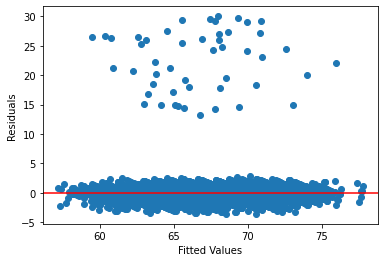

In [12]:
#residuals vs fitted values - homoscedasticity check
plt.scatter(lm.fittedvalues, res)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [13]:
df["resid"] = lm.resid

# look at largest residuals
df.sort_values("resid", ascending=False).head(60)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,resid
6176,16,83,Low,Medium,Yes,8,92,Low,Yes,2,...,High,Public,Positive,4,No,Postgraduate,Near,Female,98,30.009340
2340,23,83,High,High,Yes,4,89,Low,Yes,1,...,Medium,Public,Negative,3,No,High School,Far,Male,99,29.659224
515,15,83,Medium,Medium,No,7,97,Medium,Yes,2,...,High,Private,Neutral,2,No,High School,Near,Female,97,29.570756
4153,21,67,Medium,Medium,Yes,6,88,Medium,Yes,1,...,Medium,Private,Positive,5,No,Postgraduate,Near,Female,95,29.421768
885,21,74,High,Medium,No,6,94,Medium,Yes,1,...,High,Public,Positive,1,No,High School,Near,Male,97,29.192135
93,18,89,High,Medium,Yes,4,73,Medium,Yes,3,...,Medium,Private,Positive,2,No,College,Near,Female,100,29.130770
3454,14,90,High,High,Yes,8,86,Medium,Yes,4,...,Medium,Private,Negative,2,No,High School,Near,Female,99,29.044896
4622,1,88,Medium,High,Yes,4,72,High,Yes,3,...,Medium,Private,Negative,2,No,College,Near,Male,92,27.446763
3336,18,93,Medium,Medium,No,7,76,Low,Yes,2,...,Medium,Private,Neutral,4,No,High School,Near,Female,96,27.357087
4051,28,90,Low,Medium,Yes,9,91,Medium,Yes,0,...,Medium,Public,Positive,2,No,College,Moderate,Female,98,27.145842


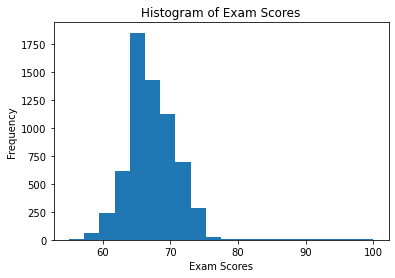

In [14]:
plt.hist(df["Exam_Score"], bins=20)
plt.title("Histogram of Exam Scores")
plt.xlabel("Exam Scores")
plt.ylabel("Frequency")
plt.show()

In [15]:
#counting observations of high performers (students with exam scores >= 78)
(df["Exam_Score"] >= 78).sum()

54

In [16]:
#counting observations with large residuals
(df["resid"] >= 10).sum()

49

In [87]:
df_avg = df[df["Exam_Score"] < 78]
df_avg = df_avg.drop(columns=['resid'])
lm_avg = smf.ols("""
Exam_Score ~ Attendance
+ Previous_Scores
+ Hours_Studied
+ C(Motivation_Level)
+ Sleep_Hours
+ Tutoring_Sessions
+ C(Family_Income)
+ C(Parental_Education_Level)
+ C(Parental_Involvement)
+ C(Teacher_Quality)
+ C(School_Type)
+ C(Learning_Disabilities)
+ C(Gender)
""", data=df_avg).fit()

lm_avg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Exam_Score   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     3523.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        16:30:52   Log-Likelihood:                -9000.8
No. Observations:                6323   AIC:                         1.804e+04
Df Residuals:                    6304   BIC:                         1.817e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                      43.3610      0.146    296.023      0.000      43.074      43.648
C(Motivation_Level)[T.Low]                     -1.0400      0.037    -28.283      0.000      -1.112      -0.968
C(Motivation_Level)[T.Medium]                  -0.4768      0.033    -14.248      0.000      -0.542      -0.411
C(Family_Income)[T.Low]                        -0.9860      0.035    -28.113      0.000      -1.055      -0.917
C(Family_Income)[T.Medium]                     -0.4779      0.035    -13.616      0.000      -0.547      -0.409
C(Parental_Education_Level)[T.High School]     -0.4703      0.029    -16.116      0.000      -0.527      -0.413
C(Parental_Education_Level)[T.Postgraduate]     0.5256      0.036     14.434      0.000       0.454       0.597
C(Parental_Involvement)[T.Low]                 -1.9470      0.037    -52.939      0.000      -2.019      -1.875
C(Parental_Involvement)[T.Medium]              -0.9767      0.030    -33.062      0.000      -1.035      -0.919
C(Teacher_Quality)[T.Low]                      -0.9626      0.046    -20.906      0.000      -1.053      -0.872
C(Teacher_Quality)[T.Medium]                   -0.4873      0.028    -17.179      0.000      -0.543      -0.432
C(School_Type)[T.Public]                       -0.0344      0.028     -1.252      0.211      -0.088       0.019
C(Learning_Disabilities)[T.Yes]                -1.0276      0.041    -24.771      0.000      -1.109      -0.946
C(Gender)[T.Male]                               0.0196      0.026      0.765      0.444      -0.031       0.070
Attendance                                      0.1984      0.001    180.851      0.000       0.196       0.201
Previous_Scores                                 0.0502      0.001     56.976      0.000       0.049       0.052
Hours_Studied                                   0.2971      0.002    139.861      0.000       0.293       0.301
Sleep_Hours                                     0.0076      0.009      0.878      0.380      -0.009       0.024
Tutoring_Sessions                               0.4976      0.010     48.484      0.000       0.477       0.518
==============================================================================
Omnibus:                       40.080   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.425
Skew:                          -0.134   Prob(JB):                     2.03e-08
Kurtosis:                       2.750   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. 

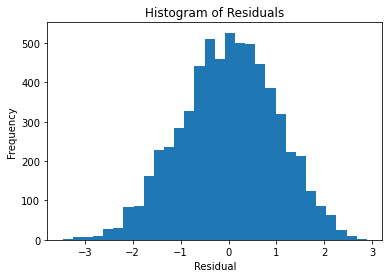

In [33]:
#plot of residuals
res_avg = lm_avg.resid

plt.hist(res_avg, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

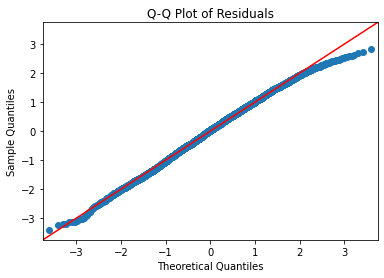

In [20]:
#checks for normality of residuals
sm.qqplot(res_avg, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

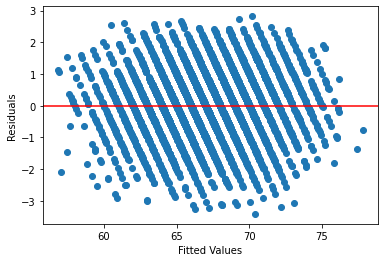

In [21]:
#residuals vs fitted values - homoscedasticity check
plt.scatter(lm_avg.fittedvalues, res_avg)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [22]:
#test for Homoscedasticity (p-values > 0.05 so the assumption of homoscedasticity holds)
het_breuschpagan(lm_avg.resid, lm_avg.model.exog)

(29.006576264210945, 0.5172512374920444, 0.9665796448941285, 0.517854361737732)

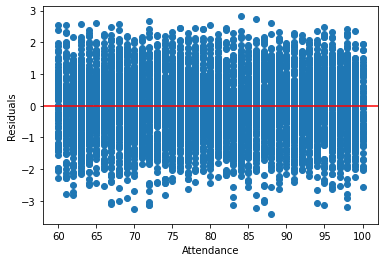

In [26]:
#Residuals vs non-categorical predictors
plt.scatter(df_avg["Attendance"], res_avg)
plt.axhline(0, color="red")
plt.xlabel("Attendance")
plt.ylabel("Residuals")
plt.show()

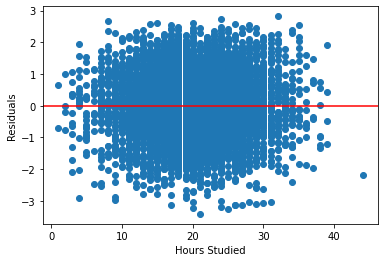

In [25]:
#Residuals vs non-categorical predictors
plt.scatter(df_avg["Hours_Studied"], res_avg)
plt.axhline(0, color="red")
plt.xlabel("Hours Studied")
plt.ylabel("Residuals")
plt.show()

Unfortunately we can not assume all observations are independent in the dataset as there may be unobserved clustering (from students who go to the same school, are from the same family, have the same teacher, etc.) which is why I use robust standard errors. Results are robust under standard OLS assumptions, though standard errors could be underestimated.

In [34]:
lm_avg_robust = lm_avg.get_robustcov_results(cov_type='HC3')
lm_avg_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Exam_Score   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     3622.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        15:02:22   Log-Likelihood:                -9000.8
No. Observations:                6323   AIC:                         1.804e+04
Df Residuals:                    6304   BIC:                         1.817e+04
Df Model:                          18                                         
Covariance Type:                  HC3                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                      43.3610      0.143    302.539      0.000      43.080      43.642
C(Motivation_Level)[T.Low]                     -1.0400      0.037    -28.329      0.000      -1.112      -0.968
C(Motivation_Level)[T.Medium]                  -0.4768      0.033    -14.316      0.000      -0.542      -0.411
C(Family_Income)[T.Low]                        -0.9860      0.035    -27.970      0.000      -1.055      -0.917
C(Family_Income)[T.Medium]                     -0.4779      0.035    -13.610      0.000      -0.547      -0.409
C(Parental_Education_Level)[T.High School]     -0.4703      0.029    -16.131      0.000      -0.527      -0.413
C(Parental_Education_Level)[T.Postgraduate]     0.5256      0.036     14.522      0.000       0.455       0.597
C(Parental_Involvement)[T.Low]                 -1.9470      0.037    -53.040      0.000      -2.019      -1.875
C(Parental_Involvement)[T.Medium]              -0.9767      0.030    -32.924      0.000      -1.035      -0.919
C(Teacher_Quality)[T.Low]                      -0.9626      0.045    -21.297      0.000      -1.051      -0.874
C(Teacher_Quality)[T.Medium]                   -0.4873      0.029    -17.082      0.000      -0.543      -0.431
C(School_Type)[T.Public]                       -0.0344      0.028     -1.242      0.214      -0.089       0.020
C(Learning_Disabilities)[T.Yes]                -1.0276      0.041    -24.765      0.000      -1.109      -0.946
C(Gender)[T.Male]                               0.0196      0.026      0.761      0.446      -0.031       0.070
Attendance                                      0.1984      0.001    180.200      0.000       0.196       0.201
Previous_Scores                                 0.0502      0.001     57.861      0.000       0.049       0.052
Hours_Studied                                   0.2971      0.002    136.918      0.000       0.293       0.301
Sleep_Hours                                     0.0076      0.009      0.889      0.374      -0.009       0.024
Tutoring_Sessions                               0.4976      0.010     48.434      0.000       0.477       0.518
==============================================================================
Omnibus:                       40.080   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.425
Skew:                          -0.134   Prob(JB):                     2.03e-08
Kurtosis:                       2.750   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 1.31e+03. This might indicate that there are
s

Check for multicollinearity:

In [38]:
X = lm_avg.model.exog
vif_df = pd.DataFrame()
vif_df["variable"] = lm_avg.model.exog_names
vif_df["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print(vif_df)

                                       variable         VIF
0                                     Intercept  134.031501
1                    C(Motivation_Level)[T.Low]    1.747840
2                 C(Motivation_Level)[T.Medium]    1.748085
3                       C(Family_Income)[T.Low]    1.851980
4                    C(Family_Income)[T.Medium]    1.851293
5    C(Parental_Education_Level)[T.High School]    1.329549
6   C(Parental_Education_Level)[T.Postgraduate]    1.329452
7                C(Parental_Involvement)[T.Low]    1.363475
8             C(Parental_Involvement)[T.Medium]    1.362269
9                     C(Teacher_Quality)[T.Low]    1.208153
10                 C(Teacher_Quality)[T.Medium]    1.205933
11                     C(School_Type)[T.Public]    1.002033
12              C(Learning_Disabilities)[T.Yes]    1.002255
13                            C(Gender)[T.Male]    1.001629
14                                   Attendance    1.003090
15                              Previous

In [74]:
#cook's distance for influenial points check
influence = lm_avg.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(df_avg)
influential_points = np.where(cooks_d > threshold)[0]
print(influential_points)

[  73   86   90   99  131  167  219  261  272  381  385  407  412  453
  517  527  550  580  584  588  638  643  646  668  681  717  757  763
  840  848  853  863  873  919 1044 1058 1073 1084 1091 1113 1148 1167
 1211 1226 1277 1311 1332 1393 1422 1435 1471 1474 1500 1512 1537 1548
 1619 1723 1756 1762 1780 1832 1833 1856 1867 1889 1949 1954 1961 2006
 2014 2051 2061 2062 2110 2112 2134 2150 2157 2169 2202 2204 2207 2228
 2264 2302 2327 2343 2357 2364 2388 2391 2405 2414 2426 2429 2431 2437
 2445 2476 2512 2544 2586 2613 2657 2666 2669 2670 2678 2717 2732 2741
 2753 2767 2772 2813 2936 2983 2995 3026 3055 3059 3094 3104 3118 3138
 3144 3291 3309 3315 3339 3340 3385 3432 3440 3441 3466 3518 3525 3555
 3568 3575 3583 3665 3691 3715 3737 3748 3761 3771 3796 3858 3866 3897
 3962 3966 4056 4057 4074 4176 4202 4231 4242 4252 4253 4293 4316 4317
 4319 4336 4391 4393 4405 4431 4452 4456 4459 4466 4468 4472 4499 4508
 4573 4579 4631 4643 4651 4744 4777 4803 4809 4816 4826 4831 4833 4855
 4925 

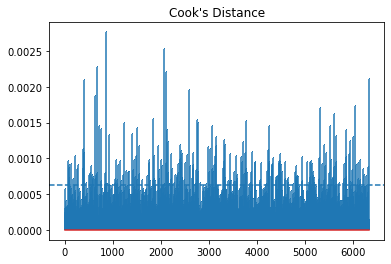

In [43]:
plt.stem(cooks_d, markerfmt=",")
plt.axhline(4/len(df_avg), linestyle='--')
plt.title("Cook's Distance")
plt.show()

In [67]:
#calulating high lev points
high_lev =2*18/len(df_avg)
leverage = influence.hat_matrix_diag

high_lev_points = np.where(leverage > high_lev)[0]
high_lev_points

array([ 244,  293,  643,  693, 1030, 1104, 1348, 1549, 1658, 1669, 1783,
       2043, 2095, 2130, 2244, 2597, 2754, 3236, 3249, 3525, 3641, 3712,
       3953, 4136, 4267, 4793, 4970, 5054, 5436, 5604, 5753, 5805, 6209],
      dtype=int64)

In [69]:
#calculating large resid points
student_resid = influence.resid_studentized_external
large_res_points = np.where(abs(student_resid)>3)[0]
large_res_points

array([ 412,  681,  863,  919, 1393, 2586, 3144, 3339, 5512, 6040, 6315],
      dtype=int64)

In [75]:
#getting intersection of large resid and high lev points (none)
large_res_and_high_lev = np.intersect1d(high_lev_points, large_res_points)
large_res_and_high_lev

0

In [85]:
#print and inspecting points with 10 largest cook's distance values
df_avg["cooks_d"] = cooks_d
df_avg.iloc[influential_points].sort_values(by='cooks_d', ascending=False).head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,cooks_d
874,24,98,Medium,Low,No,9,53,Medium,Yes,3,...,Low,Private,Negative,2,No,Postgraduate,Far,Male,69,0.002763
2083,28,72,High,Medium,Yes,5,78,Low,No,5,...,Low,Private,Negative,2,No,College,Far,Male,67,0.002535
690,27,72,Medium,Low,No,4,68,Medium,No,0,...,High,Public,Negative,3,Yes,College,Near,Male,63,0.002274
2133,24,68,Low,Low,No,6,67,High,No,0,...,High,Private,Positive,3,Yes,High School,Far,Female,60,0.002203
6369,30,94,Medium,Low,No,5,52,Low,No,3,...,Medium,Private,Neutral,2,No,Postgraduate,Moderate,Female,70,0.002116
417,26,83,Low,Low,No,7,70,High,No,2,...,High,Public,Negative,4,Yes,High School,Moderate,Male,65,0.002098
2614,21,88,Medium,Low,No,9,75,High,No,1,...,High,Private,Neutral,2,No,Postgraduate,Moderate,Female,67,0.001962
647,4,69,Medium,Low,No,9,93,Low,No,2,...,High,Private,Negative,3,No,High School,Moderate,Female,58,0.001873
6091,26,72,Medium,Low,No,8,82,Medium,Yes,2,...,Low,Public,Negative,2,No,Postgraduate,Far,Female,65,0.001733
5348,30,96,Medium,Low,Yes,4,74,High,No,0,...,Low,Public,Negative,3,No,High School,Moderate,Male,69,0.001702


In [60]:
#refitting model without potentially influencial points based on cook's distance
#no significant differences found

df_avg_ck = df_avg
df_avg_ck = df_avg.drop(index=influential_points)

lm_avg_ck = smf.ols("""
Exam_Score ~ Attendance
+ Previous_Scores
+ Hours_Studied
+ C(Motivation_Level)
+ Sleep_Hours
+ Tutoring_Sessions
+ C(Family_Income)
+ C(Parental_Education_Level)
+ C(Parental_Involvement)
+ C(Teacher_Quality)
+ C(School_Type)
+ C(Learning_Disabilities)
+ C(Gender)
""", data=df_avg_ck).fit()

lm_avg_ck.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Exam_Score   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     3378.
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        15:36:42   Log-Likelihood:                -8628.4
No. Observations:                6069   AIC:                         1.729e+04
Df Residuals:                    6050   BIC:                         1.742e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                      43.3879      0.149    290.994      0.000      43.096      43.680
C(Motivation_Level)[T.Low]                     -1.0474      0.038    -27.916      0.000      -1.121      -0.974
C(Motivation_Level)[T.Medium]                  -0.4774      0.034    -13.955      0.000      -0.545      -0.410
C(Family_Income)[T.Low]                        -0.9981      0.036    -27.921      0.000      -1.068      -0.928
C(Family_Income)[T.Medium]                     -0.4835      0.036    -13.520      0.000      -0.554      -0.413
C(Parental_Education_Level)[T.High School]     -0.4716      0.030    -15.871      0.000      -0.530      -0.413
C(Parental_Education_Level)[T.Postgraduate]     0.5157      0.037     13.909      0.000       0.443       0.588
C(Parental_Involvement)[T.Low]                 -1.9265      0.038    -51.363      0.000      -2.000      -1.853
C(Parental_Involvement)[T.Medium]              -0.9646      0.030    -32.042      0.000      -1.024      -0.906
C(Teacher_Quality)[T.Low]                      -0.9694      0.047    -20.710      0.000      -1.061      -0.878
C(Teacher_Quality)[T.Medium]                   -0.4933      0.029    -17.045      0.000      -0.550      -0.437
C(School_Type)[T.Public]                       -0.0376      0.028     -1.339      0.181      -0.093       0.017
C(Learning_Disabilities)[T.Yes]                -1.0142      0.042    -23.913      0.000      -1.097      -0.931
C(Gender)[T.Male]                               0.0210      0.026      0.802      0.423      -0.030       0.072
Attendance                                      0.1982      0.001    177.292      0.000       0.196       0.200
Previous_Scores                                 0.0503      0.001     55.996      0.000       0.049       0.052
Hours_Studied                                   0.2966      0.002    136.751      0.000       0.292       0.301
Sleep_Hours                                     0.0073      0.009      0.833      0.405      -0.010       0.025
Tutoring_Sessions                               0.4996      0.010     47.613      0.000       0.479       0.520
==============================================================================
Omnibus:                       37.566   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.949
Skew:                          -0.140   Prob(JB):                     4.25e-08
Kurtosis:                       2.764   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. 